# Tutorial 1 System with Rotation

This notebok shows how to setup an optical system and how to do some irradiance calculations with diffinytrace.

In [1]:
import sys
import os
import gc
import tqdm
sys.path.insert(0, os.path.abspath(".."))
device = "cuda:0"

In [2]:
import diffinytrace as dit
import torch

Diffinytrace implements multiple refractive indices from the RefractiveIndex.Info database; however, it is also possible to define custom materials.

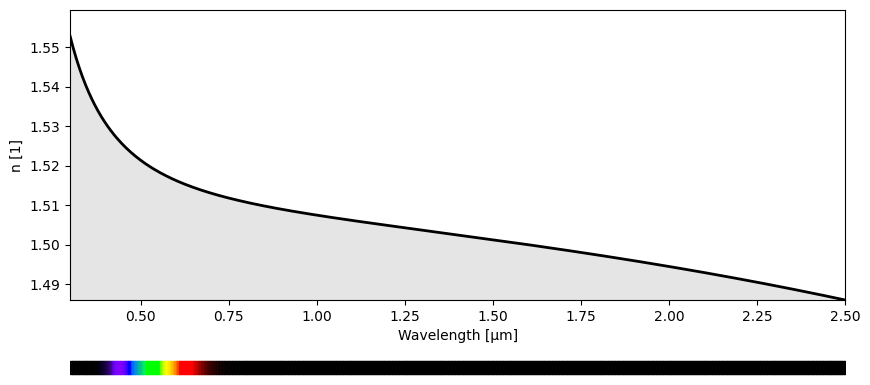

In [3]:

NBK7 = dit.materials["NBK7"]
dit.plotting.wavelength.plot(NBK7)

Defining a light source is very straightforward. All objects in Diffinytrace need to be initialized with a transform. One simple transform is the offset transform, which sets the position relative to the origin or a parent transform.

In [4]:
z_pos = 0.0
lens_thickness = 3.0

wave_len = 1.024
light_transforms = dit.transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_source = dit.source.CollimatedMonochromatic(light_transforms,8.0,wave_len)


This code defines a lens element in the optical system:

- `plane_surface = dit.Plane()`: Creates a planar surface for the front of the lens.
- `surface2 = dit.Aspheric(-1/50.)`: Creates an aspheric surface for the back of the lens with a specified curvature.
- `transf1 = dit.transforms.Distance(10.0, parent_transform=light_transforms)`: Positions the lens 10 units away from the light source using a distance transform.
- `lens1 = dit.Lens(transf1, lens_thickness, plane_surface, surface2, NBK7, 13.0)`: Constructs the lens object with the specified transform, thickness, surfaces, material (`NBK7`), and aperture radius.


In [5]:

plane_surface = dit.Plane()
surface2 = dit.Aspheric(-1/50.)
transf1 = dit.transforms.Distance(10.0,parent_transform=light_transforms)
lens1 = dit.Lens(transf1,lens_thickness,plane_surface,surface2,NBK7,13.0)

It is also possible to set a lens as the `parent_transform`. In this case, the "real" parent transform will be the last transform of the back surface of the lens. This allows to easily chain optical elements together in a sequence, ensuring that each new element is positioned relative to the previous one in the system.

In [6]:

surface3 = dit.Aspheric(-1/50.)
surface4 = dit.Aspheric(0.0)#Plane()
transf2 = dit.transforms.Distance(10.0,parent_transform=lens1)
lens2 = dit.Lens(transf2,lens_thickness,surface3,surface4,NBK7,17.0)

This code adds a mirror and a detector to the optical system:

- `transf3 = dit.transforms.Compose([dit.transforms.Distance(30., parent_transform=lens2), dit.transforms.Rotation(45., axis=0)])`: Creates a composite transform that first positions the mirror 30 units away from `lens2`, then rotates it 45 degrees around the x-axis.
- `surface5 = dit.Aspheric(-1/75.)`: Defines an aspheric surface for the mirror.
- `mirror = dit.Mirror(transf3, surface5, 25.0)`: Creates a mirror object with the specified transform, surface, and aperture radius.
- `transf4 = dit.transforms.Compose([transf3, dit.transforms.Rotation(45., axis=0), dit.transforms.Distance(-40.0)])`: Creates a composite transform for the detector by applying an additional 45-degree rotation and then moving it -40 units from the mirror.
- `detector = dit.Detector(transf4, plane_surface, 8.0)`: Creates a detector object with the specified transform, planar surface, and aperture radius.


In [7]:
transf3 = dit.transforms.Compose([dit.transforms.Distance(30.,parent_transform=lens2),dit.transforms.Rotation(45.,axis=0)])
surface5 = dit.Aspheric(-1/75.)#Plane()
mirror = dit.Mirror(transf3,surface5,25.0)
transf4 = dit.transforms.Compose([transf3,dit.transforms.Rotation(45.,axis=0),dit.transforms.Distance(-40.0)])
detector = dit.Detector(transf4,plane_surface,8.0)


Last but not least, we need to set up a sequential optical system. This takes as input a dictionary of optical elements, which will later be used during ray tracing. When tracing rays, a sequence must be provided, and the sequential optical system will perform ray tracing according to the specified order of elements.

In [8]:
system = dit.SequentialOpticalSystem({"light_source":light_source,"lens1":lens1,"mirror":mirror,"detector":detector,"lens2":lens2})

Diffinytrace also supports automated annotation of the optical system, making it easy to visualize and label each component in your setup.

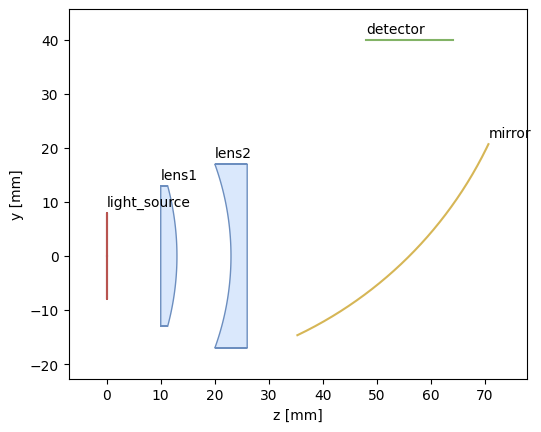

In [9]:
sequence = ["light_source","lens1","lens2","mirror","detector"]
dit.plotting.system2D.plot(system,annotate=True)


Diffinytrace also supports visualization of rays—the ray tracing is always performed in 3D, and the rays are just projected onto the y-z plane. For this reason, in 2D these rays may sometimes appear unusual, since the lens surfaces are also plotted as slices of the surfaces in the y-z plane with x = 0.

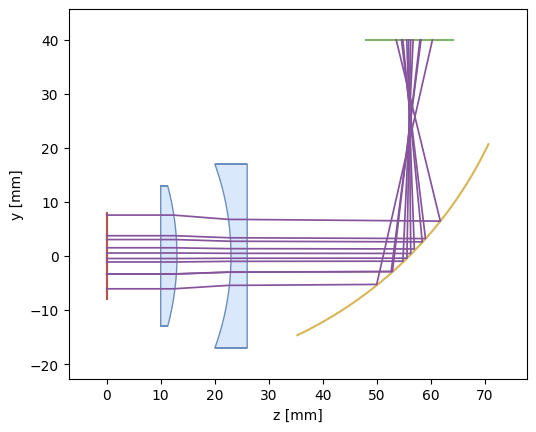

In [10]:
num_rays = 10
x,weights = light_source.sample(num_rays)
x.requires_grad = True
O,D,wave_len,_,RayPaths = system(x,sequence)
dit.plotting.system2D.plot(system,RayPaths)

Also 3D plotting is supported. Here rays always look correct since no projection is needed

In [11]:

dit.plotting.system3D.plot(system,RayPaths,resolution=24)

c:\Users\marti\anaconda3\Lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Diffiny trace also supports the calculation of the nearest ray (index) with the target grid module

<Figure size 640x480 with 0 Axes>

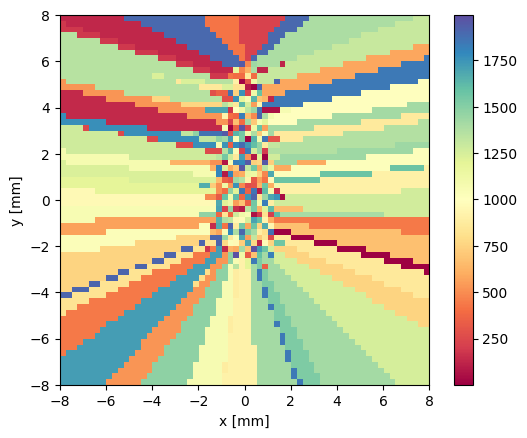

In [12]:
import matplotlib.pyplot as plt

grid = dit.target_grid.GridSquare(detector.aperture_radius,64)

from matplotlib.colors import LogNorm
num_rays = 2000
x,weights = light_source.sample(num_rays)
O,D,wave_len,_,RayPaths = system(x,sequence)
O_local = detector.to_local_pos(O)
O_local = O_local[:,[0,1]]
nearest_ray = grid.get_nearest_ray(O_local)
num_rays_on_grid = grid.sum(O_local,torch.ones((x.shape[0]),dtype=x.dtype,device=x.device))
dit.plotting.quantity2D.plot(nearest_ray,"",[-detector.aperture_radius,detector.aperture_radius],show=False,cmap="Spectral")


Also, some functions for quickly calculating irradiance using the ray counting method are implemented.

There are a couple of integration methods supported. Here, PyTorch's implementation of Sobol sampling is used by default. If `sobol_pow2` is provided as the ray tracing method, SciPy's implementation of Sobol is used, which is preferred.

<Figure size 640x480 with 0 Axes>

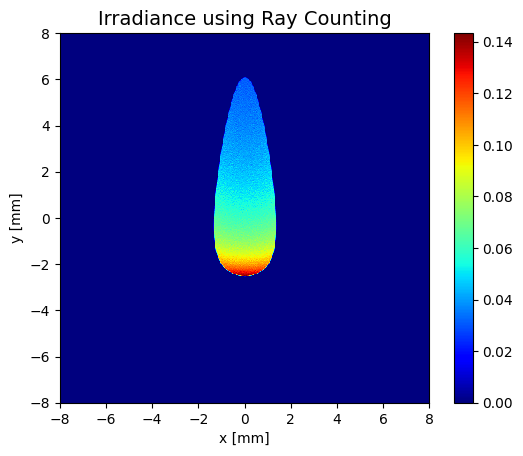

In [13]:
grid = dit.target_grid.GridSquare(detector.aperture_radius,512)
irr = dit.render.binned_irradiance(system,sequence,light_source,detector,grid,num_rays=[1000,1000],method_ray_tracing="sobol")
dit.plotting.quantity2D.plot(irr,"Irradiance using Ray Counting",[-detector.aperture_radius,detector.aperture_radius])


It is also possible to calculate the irradiance distribution with differential ray tracing which is described in "Using differential ray tracing in stray light analysis". As one can see there is no noise at all. The reason is that derivatives are used for irradiance calculation. There actually only needs to be one ray per pixel to calculate the irradiance distribution for bijective mappings of the optical system with this method.

Here another method of the target grid is also used: mean which calculates the mean over pixel of values associated with a ray

<Figure size 640x480 with 0 Axes>

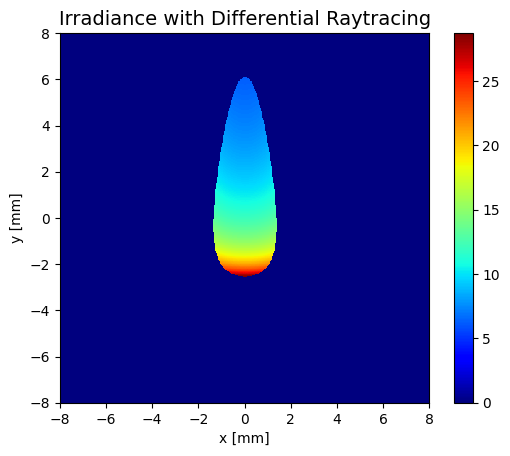

In [14]:

x,weights = light_source.sample(1000*1000)
O,D,wave_len,_,RayPaths = system(x,sequence)
O_local = detector.to_local_pos(O)
_,org_args = grid.nearest(O_local[:,[0,1]],return_args=True)
org_args = org_args.reshape(-1)
mask = org_args==-1

args = org_args[mask!=True]
xb = x.detach()
xb = xb[args]

xb.requires_grad = True
O,D,wave_len,_,RayPaths = system(xb,sequence)
O_local = detector.to_local_pos(O)
O1x, = dit.grad(O_local[:,0],xb,torch.ones_like(O_local[:,0]))
O2x, = dit.grad(O_local[:,1],xb,torch.ones_like(O_local[:,1]))

a = O1x[:,0]
b = O1x[:,1]
c = O2x[:,0]
d = O2x[:,1]
H = a*d-b*c

I = grid.mean(O_local[:,[0,1]],torch.ones((O.shape[0]))/torch.abs(H))
I = I.detach()
dit.plotting.quantity2D.plot(I,"Irradiance with Differential Raytracing",[-detector.aperture_radius,detector.aperture_radius])


As a library for algorithmic differentiable ray tracing also gaussian measurement functions are supported for the calculation of smooth irradiance distributions

<Figure size 640x480 with 0 Axes>

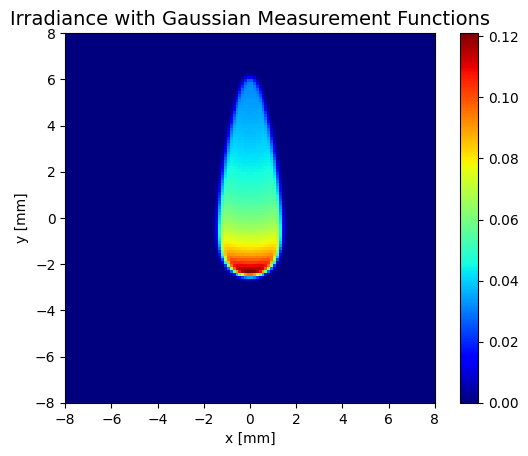

In [15]:
smoother = dit.gaussian_smoother.GaussianSmootherSquare(aperture_radius=detector.aperture_radius,sigma=0.1,grid_size=128,desired_irradiance_fun=lambda p: p[:,0],smoothed_num_integration_points=2,smoothed_num_splits=1,device=device)
smoothed_irr = dit.render.smoothed_irradiance(system,sequence,light_source,detector,smoother,num_rays=[256,256],method_ray_tracing="midpoint")
dit.plotting.quantity2D.plot(smoothed_irr,"Irradiance with Gaussian Measurement Functions",[-detector.aperture_radius,detector.aperture_radius])
